In [1]:
import os
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.cuda.amp import autocast, GradScaler
import numpy as np
import cv2
from tqdm import tqdm
import matplotlib.pyplot as plt
from torch.utils.tensorboard import SummaryWriter
import warnings
import albumentations as A
from albumentations.pytorch import ToTensorV2
from sklearn.model_selection import train_test_split
warnings.filterwarnings("ignore")

2026-03-29 21:16:57.902119: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1774819018.107067      55 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1774819018.172454      55 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1774819018.670338      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774819018.670382      55 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1774819018.670385      55 computation_placer.cc:177] computation placer alr

In [2]:
# Устройство и количество GPU
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
num_gpus = torch.cuda.device_count()
print(f"Using device: {device}")
print(f"Number of available GPUs: {num_gpus}")

# Проверка памяти на всех GPU
for i in range(num_gpus):
    free_mem = torch.cuda.mem_get_info(i)[0] / 1024**3
    print(f"GPU {i} free memory: {free_mem:.2f} GB")

Using device: cuda
Number of available GPUs: 2
GPU 0 free memory: 14.46 GB
GPU 1 free memory: 14.46 GB


In [3]:
def train_epoch(train_generator, model, loss_function, optimizer, scaler, epoch,
                accumulation_steps=1, callback=None):
    model.train()
    epoch_loss = 0
    total_samples = 0
    optimizer.zero_grad()

    with tqdm(enumerate(train_generator), total=len(train_generator), desc=f"Epoch {epoch+1}", position=0, leave=True) as pbar:
        for i, (x_batch, y_batch) in pbar:
            x_batch = x_batch.to(device)
            y_batch = y_batch.to(device)
    
            with autocast():
                output = model(x_batch)
                loss = loss_function(output, y_batch)
    
            loss = loss / accumulation_steps
            scaler.scale(loss).backward()
    
            if (i + 1) % accumulation_steps == 0:
                scaler.step(optimizer)
                scaler.update()
                optimizer.zero_grad()
    
            batch_loss_val = loss.item() * accumulation_steps
            if callback is not None:
                with torch.no_grad():
                    callback(model, batch_loss_val)
    
            epoch_loss += batch_loss_val * len(x_batch)
            total_samples += len(x_batch)

            pbar.update(1)
            pbar.set_postfix(loss=loss.item())

    if total_samples % accumulation_steps != 0:
        scaler.step(optimizer)
        scaler.update()
        optimizer.zero_grad()

    return epoch_loss / total_samples

def trainer(count_of_epoch, batch_size, dataset, model, loss_function,
            optimizer, lr=0.001, accumulation_steps=1, callback=None):
    optima = optimizer(model.parameters(), lr=lr)
    scaler = GradScaler()
    iterations = tqdm(range(count_of_epoch), desc='epoch')
    iterations.set_postfix({'train epoch loss': np.nan})

    for i, it in enumerate(iterations):
        dataloader = DataLoader(dataset, batch_size=batch_size, shuffle=True,
                                num_workers=2, pin_memory=True, drop_last=False)
        batch_generator = tqdm(dataloader, leave=False, total=len(dataloader), disable=True)

        epoch_loss = train_epoch(
            train_generator=batch_generator,
            model=model,
            loss_function=loss_function,
            optimizer=optima,
            scaler=scaler,
            epoch = i,
            accumulation_steps=accumulation_steps,
            callback=callback
        )
        iterations.set_postfix({'train epoch loss': epoch_loss})
        torch.cuda.empty_cache()

In [4]:
class BinarizationDataset(Dataset):
    def __init__(self, images_dir, masks_dir, target_size=(1024, 1024), augment=True, filenames=None):
        """
        Args:
            images_dir: путь к папке с изображениями
            masks_dir: путь к папке с масками (такие же имена, расширение .png)
            target_size: итоговый размер (height, width) после паддинга
            augment: применять ли аугментации (для train=True, val=False)
        """
        self.images_dir = images_dir
        self.masks_dir = masks_dir
        self.target_size = target_size
        self.augment = augment

        # Список файлов изображений (поддерживаемые расширения)
        if filenames is not None:
            self.filenames = filenames
        else:
            self.filenames = [
                f for f in os.listdir(images_dir)
                if f.lower().endswith(('.jpg', '.jpeg', '.png', '.JPG'))
            ]

        # Определяем синхронные геометрические преобразования
        # Они будут применяться одинаково к изображению и маске
        geometric_transforms = []

        if augment:
            # Аугментации
            geometric_transforms.extend([
                A.RandomRotate90(p=0.5),
                A.HorizontalFlip(p=0.5),
                A.Transpose(p=0.3),
                A.ShiftScaleRotate(
                    shift_limit=(-0.0625, 0.0625),
                    scale_limit=(-0.1, 0.1),
                    rotate_limit=(-45, 45),
                    border_mode=cv2.BORDER_CONSTANT,
                    fill=255,
                    fill_mask=255, # заливка для маски (фон)
                    p=0.5
                ),
            ])

        if augment:
            self.shadow_transforms = A.Compose([
                A.OneOf([
                # Тени по всему кадру
                A.RandomShadow(
                    shadow_roi=(0, 0, 1, 1),          # вся область изображения
                    num_shadows_lower=1,              # минимум теней
                    num_shadows_upper=3,              # максимум теней (можно увеличить)
                    shadow_dimension=5,               # размер тени (чем больше, тем крупнее)
                    p=1,                            # вероятность применения
                ),
                # Солнечные блики по всему кадру
                A.RandomSunFlare(
                    flare_roi=(0, 0, 1, 1),           # вся область
                    src_radius=150,                   # радиус источника
                    src_color=(255, 255, 255),        # цвет блика (белый)
                    p=1,
                ),
                # Лёгкий туман (действует глобально)
                A.RandomFog(
                    fog_coef_lower=0.1,
                    fog_coef_upper=0.3,
                    alpha_coef=0.1,                   # прозрачность тумана
                    p=1,
                ),
                # Случайные пятна/капли (имитация грязи)
                A.RandomRain(
                    slant_lower=-10,
                    slant_upper=10,
                    drop_length=20,
                    drop_width=2,
                    blur_value=3,
                    p=1,
                ),
                ], p=0.5),
            ], p=1)  # дополнительных целей нет, работаем только с image
        else:
            self.shadow_transforms = None

        # Преобразования, которые применяются всегда (и train, и val)
        geometric_transforms.extend([
            A.LongestMaxSize(
                max_size=max(target_size),
                interpolation=1,        # линейная для изображения
                mask_interpolation=0    # ближайший сосед для маски
            ),
            A.PadIfNeeded(
                min_height=target_size[0],
                min_width=target_size[1],
                border_mode=cv2.BORDER_CONSTANT,
                fill=255,                # цвет для изображения
                fill_mask=255            # цвет для маски
            ),
        ])

        self.geometric = A.Compose(
            geometric_transforms,
            additional_targets={'mask': 'image'}
        )

    def __len__(self):
        return len(self.filenames)

    def __getitem__(self, idx):
        img_name = self.filenames[idx]
        img_path = os.path.join(self.images_dir, img_name)
        # Маска должна иметь то же имя, но расширение .png
        mask_name = os.path.splitext(img_name)[0] + '.png'
        mask_path = os.path.join(self.masks_dir, mask_name)

        # Загрузка (grayscale)
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)
        if image is None or mask is None:
            raise FileNotFoundError(f"Не удалось загрузить {img_path} или {mask_path}")

        # Применяем геометрические преобразования синхронно
        augmented = self.geometric(image=image, mask=mask)
        image = augmented['image']   # numpy array (H, W), значения 0..255
        mask = augmented['mask']     # numpy array (H, W), значения 0..255

        if self.shadow_transforms is not None:
            # Конвертируем grayscale -> RGB (временное)
            image_3ch = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
            # Применяем трансформации (они работают с RGB)
            augmented_img = self.shadow_transforms(image=image_3ch)
            image_3ch = augmented_img['image']
            # Возвращаемся к grayscale
            image = cv2.cvtColor(image_3ch, cv2.COLOR_RGB2GRAY)

        # Нормализация изображения: [0, 255] -> [-1, 1]
        image = image.astype(np.float32) / 255.0          # теперь [0, 1]
        image = (image - 0.5) / 0.5                       # теперь [-1, 1]

        # Маску просто переводим в float и делим на 255, чтобы получить [0, 1]
        mask = mask.astype(np.float32) / 255.0            # значения 0 или 1 (бинарная)

        # Изображение: добавляем размерность канала (C=1)
        image_tensor = torch.from_numpy(image).unsqueeze(0)   # (1, H, W)
        mask_tensor = torch.from_numpy(mask).unsqueeze(0)     # (1, H, W)

        return image_tensor, mask_tensor

In [5]:
class DoubleConv(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(in_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, 3, padding=1),
            nn.BatchNorm2d(out_ch),
            nn.ReLU(inplace=True)
        )

    def forward(self, x):
        return self.conv(x)

class Down(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.mp = nn.MaxPool2d(2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x):
        return self.conv(self.mp(x))

class Up(nn.Module):
    def __init__(self, in_ch, out_ch):
        super().__init__()
        self.up = nn.ConvTranspose2d(in_ch, in_ch//2, 2, stride=2)
        self.conv = DoubleConv(in_ch, out_ch)

    def forward(self, x1, x2):
        x1 = self.up(x1)
        diffY = x2.size()[2] - x1.size()[2]
        diffX = x2.size()[3] - x1.size()[3]
        x1 = nn.functional.pad(x1, [diffX // 2, diffX - diffX // 2,
                                    diffY // 2, diffY - diffY // 2])
        return self.conv(torch.cat([x2, x1], dim=1))

class UNetTiny(nn.Module):
    def __init__(self, in_channels=1, out_channels=1):
        super().__init__()
        self.inc = DoubleConv(in_channels, 8)
        
        self.down1 = Down(8, 16)
        self.down2 = Down(16, 32)
        self.down3 = Down(32, 64)
        
        self.up1 = Up(64, 32)
        self.up2 = Up(32, 16)
        self.up3 = Up(16, 8)
        
        self.outc = nn.Conv2d(8, out_channels, kernel_size=1)

    def forward(self, x):
        x1 = self.inc(x)
        x2 = self.down1(x1)
        x3 = self.down2(x2)
        x4 = self.down3(x3)

        x = self.up1(x4, x3)
        x = self.up2(x, x2)
        x = self.up3(x, x1)
        return self.outc(x)

In [6]:
class UNetCallback:
    def __init__(self, writer, dataset, loss_function, delimiter=100, batch_size=2):
        self.step = 0
        self.writer = writer
        self.delimiter = delimiter
        self.loss_function = loss_function
        self.batch_size = batch_size
        self.dataset = dataset

    def forward(self, model, loss):
        self.step += 1
        self.writer.add_scalar('LOSS/train', loss, self.step)

        if self.step % self.delimiter == 0:
            dataloader = DataLoader(self.dataset, batch_size=self.batch_size, shuffle=True)
            model.eval()
            test_loss = 0
            total = 0

            with torch.no_grad():
                for i, (x_batch, y_batch) in enumerate(dataloader):
                    x_batch = x_batch.to(device)
                    y_batch = y_batch.to(device)

                    with autocast():
                        output = model(x_batch)
                        loss_val = self.loss_function(output, y_batch).item()

                    test_loss += loss_val * len(x_batch)
                    total += len(x_batch)

                    if i == 0:
                        n = min(4, x_batch.size(0))
                        fig, axes = plt.subplots(3, n, figsize=(n*2, 6))
                        for j in range(n):
                            axes[0, j].imshow(x_batch[j, 0].cpu(), cmap='gray')
                            axes[0, j].set_title('Input')
                            axes[0, j].axis('off')

                            pred = torch.sigmoid(output[j, 0]).cpu()
                            axes[1, j].imshow(pred, cmap='gray')
                            axes[1, j].set_title('Pred')
                            axes[1, j].axis('off')

                            axes[2, j].imshow(y_batch[j, 0].cpu(), cmap='gray')
                            axes[2, j].set_title('GT')
                            axes[2, j].axis('off')

                        self.writer.add_figure('VISUAL/predictions', fig, self.step)
                        plt.close(fig)
                        break

                test_loss /= total
                self.writer.add_scalar('LOSS/test', test_loss, self.step)
            model.train()

    def __call__(self, model, loss):
        self.forward(model, loss)

## Кусок кода для показа как проходит аугментаци:

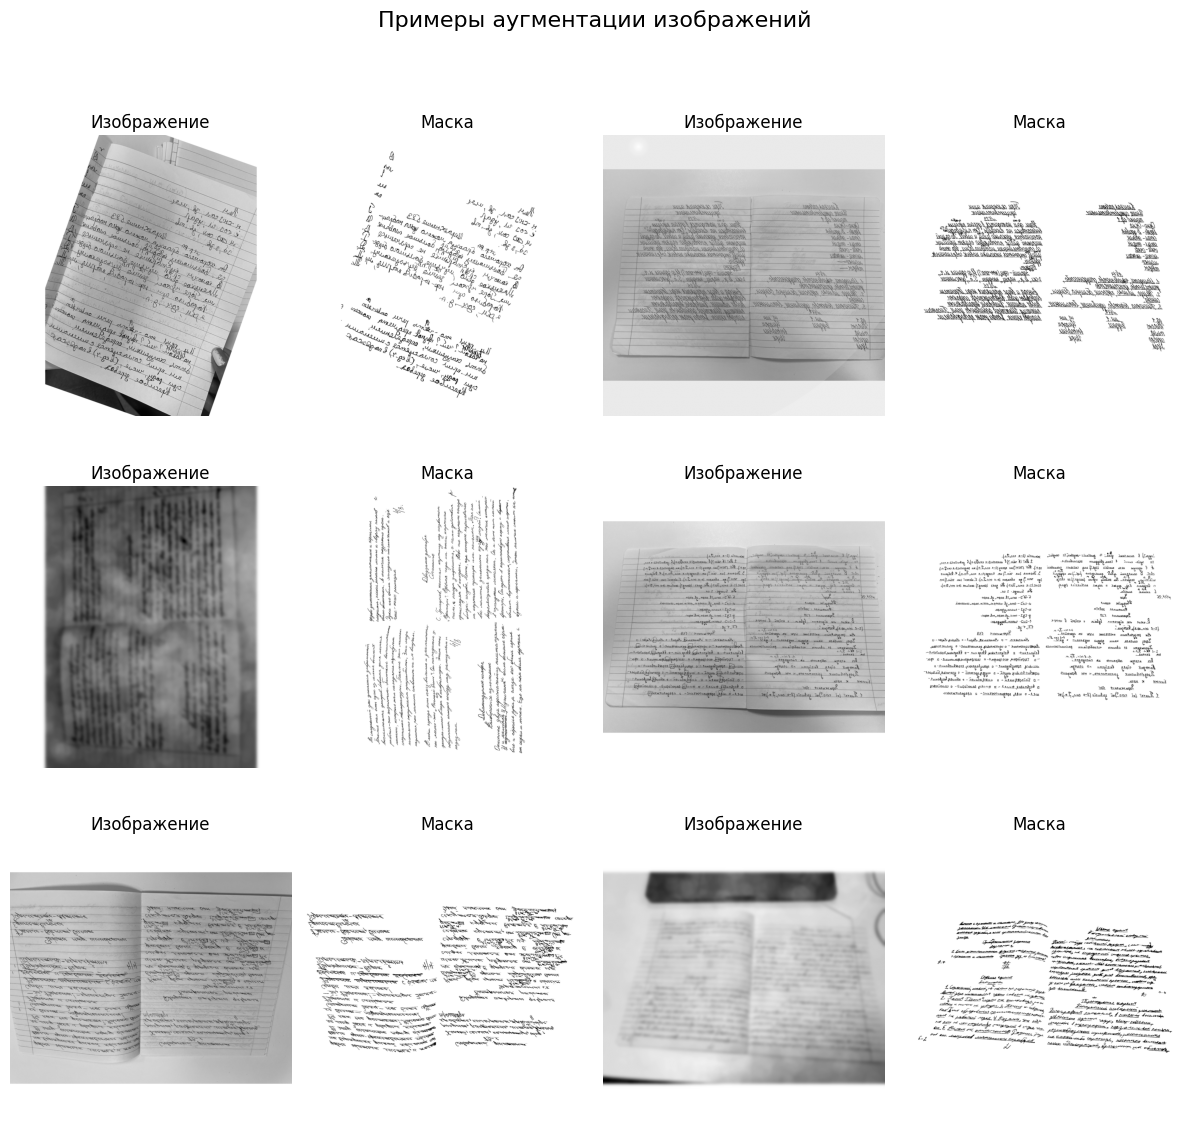

Изображение сохранено как: binarization_examples.png


In [12]:
import matplotlib.pyplot as plt
import numpy as np
from IPython.display import FileLink

images_dir = "/kaggle/input/datasets/bobrzol123/images-base/images_base"
masks_dir = "/kaggle/input/datasets/bobrzol123/images-binary/images_binary"
target_size = (2048, 2048)   # если всё равно OOM — уменьши до (2048, 2048)

dataset = BinarizationDataset(images_dir, masks_dir, target_size=target_size)
train_size = int(0.9 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(dataset, [train_size, val_size])

def denormalize(image_tensor):
    """Преобразует нормализованное изображение [-1, 1] -> [0, 1] для отображения"""
    return (image_tensor + 1) / 2

def save_examples(dataset, num_examples=6, cols=2, filename="dataset_examples.png"):
    """Сохраняет примеры в файл и предлагает скачать"""
    rows = (num_examples + cols - 1) // cols
    fig, axes = plt.subplots(rows, cols * 2, figsize=(cols * 6, rows * 4))
    
    indices = np.random.choice(len(dataset), num_examples, replace=False)
    
    for i, idx in enumerate(indices):
        image_tensor, mask_tensor = dataset[idx]
        
        image = denormalize(image_tensor).squeeze(0).numpy()
        mask = mask_tensor.squeeze(0).numpy()
        
        row = i // cols
        col = (i % cols) * 2
        
        # Изображение
        axes[row, col].imshow(image, cmap='gray')
        axes[row, col].set_title('Изображение')
        axes[row, col].axis('off')
        
        # Маска
        axes[row, col + 1].imshow(mask, cmap='gray', vmin=0, vmax=1)
        axes[row, col + 1].set_title('Маска')
        axes[row, col + 1].axis('off')
    
    plt.suptitle('Примеры аугментации изображений', fontsize=16)
    plt.tight_layout(rect=[0, 0, 1, 0.96])
    
    # Сохраняем в файл
    plt.savefig(filename, dpi=300, bbox_inches='tight')
    plt.show()
    
    print(f"Изображение сохранено как: {filename}")
    
    # Создаём ссылку для скачивания в Kaggle
    return FileLink(filename)

# Использование:
saved_file = save_examples(train_dataset, num_examples=6, cols=2, 
                           filename="binarization_examples.png")

In [8]:
images_dir = "/kaggle/input/datasets/bobrzol123/images-base/images_base"
masks_dir = "/kaggle/input/datasets/bobrzol123/images-binary/images_binary"
target_size = (3000, 3000)   # если всё равно OOM — уменьши до (2048, 2048)


all_filenames = [
    f for f in os.listdir(images_dir)
    if f.lower().endswith(('.jpg', '.jpeg', '.png', '.JPG'))
]

# Разделяем на train (90%) и val (10%) с фиксированным random_state для воспроизводимости
train_files, val_files = train_test_split(
    all_filenames, 
    test_size=0.1, 
    random_state=42
)

# Создаём датасеты
train_dataset = BinarizationDataset(
    images_dir, masks_dir, 
    target_size=target_size, 
    augment=True,           # аугментации только для train
    filenames=train_files
)

val_dataset = BinarizationDataset(
    images_dir, masks_dir, 
    target_size=target_size, 
    augment=False,          # без аугментаций
    filenames=val_files
)

print(f"Train: {len(train_dataset)}, Val: {len(val_dataset)}")


model = UNetTiny(in_channels=1, out_channels=1)

# Оборачиваем в DataParallel если GPU > 1
if num_gpus > 1:
    model = nn.DataParallel(model)
    print(f"DataParallel включён на {num_gpus} GPU")

model = model.to(device)

loss_function = nn.BCEWithLogitsLoss()
optimizer = optim.Adam

writer = SummaryWriter('./runs/unet_binarization')
callback = UNetCallback(writer, val_dataset, loss_function, delimiter=100, batch_size=2)

batch_size = 5
accumulation_steps = 1

# Обучение
trainer(
    count_of_epoch=10,
    batch_size=batch_size,
    dataset=train_dataset,
    model=model,
    loss_function=loss_function,
    optimizer=optimizer,
    lr=0.001,
    accumulation_steps=accumulation_steps,
    callback=callback
)

Train: 1671, Val: 186
DataParallel включён на 2 GPU


epoch:  50%|█████     | 5/10 [2:08:14<2:08:14, 1538.86s/it, train epoch loss=0.041]


KeyboardInterrupt: 

In [9]:
# Сохранение (учитываем DataParallel)
if isinstance(model, nn.DataParallel):
    torch.save(model.module.state_dict(), "unet_binarization.pth")
else:
    torch.save(model.state_dict(), "unet_binarization.pth")

writer.close()
print("Training finished.")

Training finished.
